In [1]:
# -*- coding: utf-8 -*-
"""
Пакетное исследование политопного подхода к детекции зевка.
Сравнение с покадровой проверкой на наборе видео с адаптивной калибровкой.

Используется формула MAR Dlib-стиль с тремя вертикальными замерами:
  MAR = (|P80-P82| + |P13-P14| + |P312-P317|) / (3 × |P78-P308|)

Коэффициенты K рассчитаны на датасете YawnDD научным модулем.

Выполняет:
  - загрузку всех видео из указанной папки
  - сбор кадров с лицом и извлечение метрик (MAR, EAR, расстояние нос-подбородок)
  - адаптивную калибровку по нейтральным кадрам для каждого видео
  - сравнение покадрового и политопного методов детекции зевка
  - визуализацию сводных результатов по всем видео
  - генерацию текстового отчета

Авторы: Волкова Н.В.
Версия: 2.0 (ВКР)
"""

import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from collections import deque
import os
from pathlib import Path
from datetime import datetime
import random

# ============================================================
# ФИКСАЦИЯ СЛУЧАЙНЫХ ФАКТОРОВ
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print("Библиотеки загружены. Случайные факторы зафиксированы.")

Библиотеки загружены. Случайные факторы зафиксированы.


In [2]:
class BatchAnalysisConfig:
    """
    Конфигурация пакетного анализа видео.

    Атрибуты:
        VIDEO_DIR: путь к папке с видеофайлами
        OUTPUT_DIR: путь для сохранения результатов
        POLYTOPE_WINDOW: размер окна политопа в кадрах
        K_MAR, K_NOSE_CHIN, K_EAR: коэффициенты из научного модуля
        MAR_CLOSED_THRESHOLD: порог MAR для закрытого рта при калибровке
        EAR_OPEN_THRESHOLD: порог EAR для открытых глаз при калибровке
        VIDEO_EXTENSIONS: поддерживаемые расширения видеофайлов
    """

    VIDEO_DIR = Path("test_videos")
    OUTPUT_DIR = Path("batch_results_dlib_mar")

    POLYTOPE_WINDOW = 15

    # Коэффициенты из научного модуля (Dlib-стиль MAR)
    K_MAR = 7.26
    K_NOSE_CHIN = 1.38
    K_EAR = 0.6

    # Пороги для отбора нейтральных кадров
    MAR_CLOSED_THRESHOLD = 0.09
    EAR_OPEN_THRESHOLD = 0.20

    VIDEO_EXTENSIONS = {'.avi', '.mp4', '.mov', '.mkv', '.webm'}

    def __init__(self):
        self.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        (self.OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
        (self.OUTPUT_DIR / "data").mkdir(parents=True, exist_ok=True)


config = BatchAnalysisConfig()
print("Конфигурация загружена.")
print(f"  Папка с видео: {config.VIDEO_DIR}")
print(f"  Папка результатов: {config.OUTPUT_DIR}")
print(f"  Окно политопа: {config.POLYTOPE_WINDOW} кадров")
print(f"  K_MAR: {config.K_MAR}")
print(f"  K_NOSE_CHIN: {config.K_NOSE_CHIN}")
print(f"  K_EAR: {config.K_EAR}")

Конфигурация загружена.
  Папка с видео: test_videos
  Папка результатов: batch_results_dlib_mar
  Окно политопа: 15 кадров
  K_MAR: 7.26
  K_NOSE_CHIN: 1.38
  K_EAR: 0.6


In [3]:
class FaceMetricsExtractor:
    """
    Извлечение геометрических метрик лица.

    Формула MAR: Dlib-стиль с тремя вертикальными замерами.
    """

    MAR_TOP_LEFT = 80
    MAR_BOTTOM_LEFT = 82
    MAR_TOP_CENTER = 13
    MAR_BOTTOM_CENTER = 14
    MAR_TOP_RIGHT = 312
    MAR_BOTTOM_RIGHT = 317
    MAR_LEFT_CORNER = 78
    MAR_RIGHT_CORNER = 308

    LEFT_EYE_IDX = [362, 385, 387, 263, 373, 380]
    RIGHT_EYE_IDX = [33, 160, 158, 133, 153, 144]

    NOSE_TIP_IDX = 1
    CHIN_IDX = 152
    LEFT_EYE_OUTER = 33
    RIGHT_EYE_OUTER = 263

    def __init__(self):
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = None

    def initialize(self):
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def release(self):
        if self.face_mesh is not None:
            self.face_mesh.close()

    def compute_mar(self, landmarks, w, h):
        """MAR по Dlib-стилю с тремя вертикальными замерами."""
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])

        v_left = np.linalg.norm(pt(self.MAR_TOP_LEFT) - pt(self.MAR_BOTTOM_LEFT))
        v_center = np.linalg.norm(pt(self.MAR_TOP_CENTER) - pt(self.MAR_BOTTOM_CENTER))
        v_right = np.linalg.norm(pt(self.MAR_TOP_RIGHT) - pt(self.MAR_BOTTOM_RIGHT))
        horizontal = np.linalg.norm(pt(self.MAR_LEFT_CORNER) - pt(self.MAR_RIGHT_CORNER))

        if horizontal < 1e-6:
            return 0.0
        return (v_left + v_center + v_right) / (3.0 * horizontal)

    def compute_ear(self, landmarks, eye_idx, w, h):
        """Eye Aspect Ratio для одного глаза."""
        pts = np.array([[landmarks[i].x * w, landmarks[i].y * h] for i in eye_idx])
        vertical = (np.linalg.norm(pts[1] - pts[5]) + np.linalg.norm(pts[2] - pts[4]))
        horizontal = 2.0 * np.linalg.norm(pts[0] - pts[3])
        return vertical / (horizontal + 1e-6)

    def compute_nose_chin(self, landmarks, w, h):
        """Нормализованное расстояние нос-подбородок."""
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
        nose = pt(self.NOSE_TIP_IDX)
        chin = pt(self.CHIN_IDX)
        left_eye = pt(self.LEFT_EYE_OUTER)
        right_eye = pt(self.RIGHT_EYE_OUTER)
        absolute = np.linalg.norm(nose - chin)
        face_w = np.linalg.norm(left_eye - right_eye)
        return absolute / face_w if face_w > 0 else 0.85

In [4]:
class PolytopeDetector:
    """Детектор на основе политопного представления."""

    def __init__(self, window_size, mar_threshold, ear_threshold):
        self.window_size = window_size
        self.mar_threshold = mar_threshold
        self.ear_threshold = ear_threshold
        self.mar_buffer = deque(maxlen=window_size)
        self.ear_buffer = deque(maxlen=window_size)

    def add_frame(self, mar, ear):
        self.mar_buffer.append(mar)
        self.ear_buffer.append(ear)

    def is_full(self):
        return len(self.mar_buffer) >= self.window_size

    def check_yawn(self):
        if not self.is_full():
            return False
        return min(self.mar_buffer) >= self.mar_threshold

    def check_eyes_closed(self):
        if not self.is_full():
            return False
        return max(self.ear_buffer) < self.ear_threshold

In [5]:
class SingleVideoAnalyzer:
    """
    Анализ одного видео с адаптивной калибровкой.

    Калибровка: поиск нейтральных кадров (рот закрыт, глаза открыты)
    по всему видео. Базовый MAR — реальная медиана этих кадров.
    Видео исключается, если нейтральных кадров менее 10%.

    Сравнение методов выполняется на уровне СОБЫТИЙ.
    """

    def __init__(self, config, extractor):
        self.config = config
        self.extractor = extractor

    def count_events(self, detection_array):
        """
        Подсчет уникальных событий в бинарном массиве.
        Событие — непрерывная последовательность True.
        """
        events = 0
        in_event = False
        for val in detection_array:
            if val and not in_event:
                events += 1
                in_event = True
            elif not val:
                in_event = False
        return events

    def analyze(self, video_path):
        """Полный анализ одного видео."""
        video_name = video_path.stem

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            print(f"  Не удалось открыть: {video_path.name}")
            return None

        actual_fps = cap.get(cv2.CAP_PROP_FPS)
        if actual_fps <= 0:
            actual_fps = 30.0

        self.extractor.initialize()
        all_frames = []
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = self.extractor.face_mesh.process(rgb)
            if res.multi_face_landmarks:
                landmarks = res.multi_face_landmarks[0].landmark
                h, w = frame.shape[:2]
                mar = self.extractor.compute_mar(landmarks, w, h)
                ear_l = self.extractor.compute_ear(
                    landmarks, self.extractor.LEFT_EYE_IDX, w, h
                )
                ear_r = self.extractor.compute_ear(
                    landmarks, self.extractor.RIGHT_EYE_IDX, w, h
                )
                ear = (ear_l + ear_r) / 2.0
                nose_chin = self.extractor.compute_nose_chin(
                    landmarks, w, h
                )
                all_frames.append({
                    'idx': frame_idx,
                    'time_sec': frame_idx / actual_fps,
                    'mar': mar,
                    'ear': ear,
                    'nose_chin': nose_chin
                })
            frame_idx += 1

        cap.release()
        self.extractor.release()

        if len(all_frames) < 30:
            print(f"  {video_name}: исключено — всего {len(all_frames)} "
                  f"кадров с лицом, требуется >= 30")
            return None

        df_video = pd.DataFrame(all_frames)

        # Калибровка по нейтральным кадрам
        neutral_mask = (
            (df_video['mar'] < self.config.MAR_CLOSED_THRESHOLD) &
            (df_video['ear'] > self.config.EAR_OPEN_THRESHOLD)
        )
        neutral_frames = df_video[neutral_mask].copy()

        # Проверка достаточности нейтральных кадров
        neutral_ratio = len(neutral_frames) / len(df_video)
        if neutral_ratio < 0.10:
            print(f"  {video_name}: исключено — нейтральных кадров "
                  f"{len(neutral_frames)} ({neutral_ratio*100:.1f}%), "
                  f"требуется >= 10%")
            return None

        # Базовые значения — реальные медианы нейтральных кадров
        mar_baseline = neutral_frames['mar'].median()
        ear_baseline = neutral_frames['ear'].median()
        nose_chin_baseline = neutral_frames['nose_chin'].median()

        # Индивидуальные пороги
        mar_threshold = mar_baseline * self.config.K_MAR
        nose_chin_threshold = nose_chin_baseline * self.config.K_NOSE_CHIN
        ear_threshold = ear_baseline * self.config.K_EAR

        print(f"  Нейтр: {len(neutral_frames)} "
              f"({neutral_ratio*100:.1f}%), "
              f"MAR баз: {mar_baseline:.4f}, "
              f"MAR порог: {mar_threshold:.4f}")

        # Сравнение методов
        polytope = PolytopeDetector(
            window_size=self.config.POLYTOPE_WINDOW,
            mar_threshold=mar_threshold,
            ear_threshold=ear_threshold
        )

        frame_yawn_arr = np.zeros(len(df_video), dtype=bool)
        poly_yawn_arr = np.zeros(len(df_video), dtype=bool)

        for i, (_, row) in enumerate(df_video.iterrows()):
            mar = row['mar']
            ear = row['ear']
            frame_yawn_arr[i] = mar >= mar_threshold
            polytope.add_frame(mar, ear)
            poly_yawn_arr[i] = polytope.check_yawn()

        # Подсчет кадров (для справки)
        frame_yawn_cadrs = frame_yawn_arr.sum()
        poly_yawn_cadrs = poly_yawn_arr.sum()

        # Подсчет событий (основная метрика)
        frame_yawn_events = self.count_events(frame_yawn_arr)
        poly_yawn_events = self.count_events(poly_yawn_arr)

        # Ложные события
        false_events = max(0, frame_yawn_events - poly_yawn_events)

        reduction_pct = (
            (frame_yawn_events - poly_yawn_events) /
            max(frame_yawn_events, 1) * 100
        )

        data_path = (
            self.config.OUTPUT_DIR / "data" / f"{video_name}_metrics.csv"
        )
        df_video.to_csv(data_path, index=False)

        return {
            'video_name': video_name,
            'total_frames': len(df_video),
            'neutral_frames': len(neutral_frames),
            'neutral_ratio': neutral_ratio,
            'mar_baseline': mar_baseline,
            'mar_threshold': mar_threshold,
            'ear_baseline': ear_baseline,
            'ear_threshold': ear_threshold,
            'nose_chin_baseline': nose_chin_baseline,
            'nose_chin_threshold': nose_chin_threshold,
            'frame_yawn_cadrs': int(frame_yawn_cadrs),
            'poly_yawn_cadrs': int(poly_yawn_cadrs),
            'frame_yawn_events': int(frame_yawn_events),
            'poly_yawn_events': int(poly_yawn_events),
            'false_events': int(false_events),
            'reduction_pct': reduction_pct
        }

In [6]:
class BatchComparator:
    """Пакетное сравнение методов на уровне событий."""

    def __init__(self, config, analyzer):
        self.config = config
        self.analyzer = analyzer

    def count_events(self, detection_array):
        """
        Подсчет уникальных событий в бинарном массиве.
        Событие — непрерывная последовательность True.
        """
        events = 0
        in_event = False
        for val in detection_array:
            if val and not in_event:
                events += 1
                in_event = True
            elif not val:
                in_event = False
        return events

    def run(self):
        """Запуск пакетного анализа."""
        video_dir = self.config.VIDEO_DIR
        if not video_dir.exists():
            raise FileNotFoundError(f"Папка не найдена: {video_dir}")

        video_paths = []
        for ext in self.config.VIDEO_EXTENSIONS:
            video_paths.extend(video_dir.glob(f"*{ext}"))
            video_paths.extend(video_dir.glob(f"*{ext.upper()}"))
        video_paths = sorted(set(video_paths))

        print(f"Найдено видео: {len(video_paths)}")

        all_results = []
        for i, vp in enumerate(video_paths):
            print(f"\n[{i+1}/{len(video_paths)}] {vp.name}")
            result = self.analyzer.analyze(vp)
            if result:
                all_results.append(result)

        if not all_results:
            return None

        df_results = pd.DataFrame(all_results)
        df_results = df_results.sort_values('reduction_pct', ascending=False)
        df_results.to_csv(
            self.config.OUTPUT_DIR / "batch_results.csv", index=False
        )
        return df_results

In [10]:
class BatchVisualizer:
    """Визуализация результатов пакетного анализа."""

    def __init__(self, config):
        self.config = config
        self.output_dir = config.OUTPUT_DIR / "plots"

    def plot_summary(self, df_results):
        """Построение сводных графиков."""
        if df_results is None or len(df_results) == 0:
            return

        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        video_names = df_results['video_name'].values

        # График 1: Сравнение СОБЫТИЙ
        ax = axes[0, 0]
        x = np.arange(len(video_names))
        width = 0.35
        ax.bar(x - width/2, df_results['frame_yawn_events'], width,
               label='Покадровый', color='lightcoral', edgecolor='black')
        ax.bar(x + width/2, df_results['poly_yawn_events'], width,
               label='Политопный', color='steelblue', edgecolor='black')
        ax.set_xticks(x)
        ax.set_xticklabels(video_names, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Событий')
        ax.set_title('Сравнение количества событий')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        # График 2: Процент снижения событий
        ax = axes[0, 1]
        colors = ['green' if v > 0 else 'gray' for v in df_results['reduction_pct']]
        ax.bar(video_names, df_results['reduction_pct'], color=colors, edgecolor='black')
        ax.set_xticklabels(video_names, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Снижение событий (%)')
        ax.set_title('Эффективность политопа (на уровне событий)')
        ax.grid(True, alpha=0.3, axis='y')

        # График 3: Адаптивные пороги
        ax = axes[1, 0]
        x = np.arange(len(video_names))
        ax.scatter(x, df_results['mar_baseline'], marker='o', s=80,
                   label='Базовый MAR', color='green', zorder=3)
        ax.scatter(x, df_results['mar_threshold'], marker='^', s=80,
                   label='Порог MAR', color='red', zorder=3)
        for i in range(len(video_names)):
            ax.plot([i, i], [df_results['mar_baseline'].iloc[i],
                             df_results['mar_threshold'].iloc[i]], 'k--', alpha=0.3)
        ax.set_xticks(x)
        ax.set_xticklabels(video_names, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('MAR (Dlib-стиль)')
        ax.set_title('Адаптивные пороги MAR (индивидуальные)')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # График 4: Ложные события
        ax = axes[1, 1]
        ax.bar(video_names, df_results['false_events'],
               color='orange', edgecolor='black')
        ax.set_xticklabels(video_names, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Событий')
        ax.set_title('Ложные события покадрового метода')
        ax.grid(True, alpha=0.3, axis='y')

        plt.suptitle(
            f'Сравнение методов на уровне СОБЫТИЙ (Dlib-стиль MAR, K_MAR={config.K_MAR})\n'
            f'Видео: {len(df_results)}, окно политопа: {config.POLYTOPE_WINDOW} кадров',
            fontsize=14
        )
        plt.tight_layout()
        plot_path = self.output_dir / "batch_summary.png"
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"График сохранен: {plot_path}")

In [11]:
class ReportGenerator:
    """Генерация итогового отчета."""

    def __init__(self, config):
        self.config = config

    def generate(self, df_results):
        """Генерация текстового отчета."""
        if df_results is None or len(df_results) == 0:
            return

        lines = []
        lines.append("=" * 60)
        lines.append("ОТЧЕТ: СРАВНЕНИЕ МЕТОДОВ ДЕТЕКЦИИ ЗЕВКА")
        lines.append("=" * 60)
        lines.append(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        lines.append(f"Видео: {len(df_results)}")
        lines.append(f"Формула MAR: Dlib-стиль (3 замера)")
        lines.append(f"K_MAR: {config.K_MAR}, K_NOSE_CHIN: {config.K_NOSE_CHIN}")
        lines.append(f"Окно политопа: {config.POLYTOPE_WINDOW} кадров")
        lines.append("")
        lines.append("Метрика: СРАВНЕНИЕ НА УРОВНЕ СОБЫТИЙ")
        lines.append("Событие = непрерывная последовательность кадров с зевком.")
        lines.append("")

        total_frame_cadrs = df_results['frame_yawn_cadrs'].sum()
        total_poly_cadrs = df_results['poly_yawn_cadrs'].sum()
        total_frame_events = df_results['frame_yawn_events'].sum()
        total_poly_events = df_results['poly_yawn_events'].sum()
        total_false_events = df_results['false_events'].sum()
        avg_reduction = df_results['reduction_pct'].mean()
        median_reduction = df_results['reduction_pct'].median()

        lines.append("1. СВОДНАЯ СТАТИСТИКА:")
        lines.append("-" * 40)
        lines.append(f"  Покадровых кадров: {total_frame_cadrs}")
        lines.append(f"  Политопных кадров: {total_poly_cadrs}")
        lines.append(f"  Покадровых событий: {total_frame_events}")
        lines.append(f"  Политопных событий: {total_poly_events}")
        lines.append(f"  Ложных событий:     {total_false_events}")
        if total_frame_events > 0:
            lines.append(f"  Общее снижение: {(total_frame_events-total_poly_events)/total_frame_events*100:.1f}%")
        lines.append(f"  Среднее снижение по видео: {avg_reduction:.1f}%")
        lines.append(f"  Медианное снижение: {median_reduction:.1f}%")
        lines.append("")

        lines.append("2. АДАПТИВНЫЕ ПОРОГИ И СОБЫТИЯ ПО ВИДЕО:")
        lines.append("-" * 40)
        for _, row in df_results.iterrows():
            lines.append(f"  {row['video_name']}:")
            lines.append(f"    Базовый MAR: {row['mar_baseline']:.4f}, "
                         f"Порог: {row['mar_threshold']:.4f}")
            lines.append(f"    Событий: покадровых {row['frame_yawn_events']}, "
                         f"политопных {row['poly_yawn_events']}, "
                         f"ложных {row['false_events']}, "
                         f"снижение {row['reduction_pct']:.1f}%")
        lines.append("")

        lines.append("3. НАУЧНЫЕ ВЫВОДЫ:")
        lines.append("-" * 40)
        lines.append(f"  Dlib-стиль MAR с тремя вертикальными замерами")
        lines.append(f"  обеспечивает индивидуальную вариативность")
        lines.append(f"  базового MAR (значения различаются у разных водителей).")
        lines.append(f"  Политопный подход на уровне событий снижает")
        lines.append(f"  количество ложных срабатываний в среднем")
        lines.append(f"  на {avg_reduction:.1f}% (медианно {median_reduction:.1f}%).")
        lines.append(f"  Метрика на уровне событий исключает артефакты")
        lines.append(f"  на границах зевка (начало и конец).")

        report_path = self.config.OUTPUT_DIR / "batch_report.txt"
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines))
        print('\n'.join(lines))
        print(f"\nОтчет сохранен: {report_path}")

ПАКЕТНЫЙ АНАЛИЗ: ПОЛИТОП vs ПОКАДРОВЫЙ (DLIB-СТИЛЬ MAR)

ЭТАП 1: АНАЛИЗ ВИДЕО
Найдено видео: 29

[1/29] 1-FemaleNoGlasses.avi
  Нейтр: 954 (34.8%), MAR баз: 0.0695, MAR порог: 0.5048

[2/29] 1-MaleGlasses.avi
  Нейтр: 610 (23.7%), MAR баз: 0.0755, MAR порог: 0.5480

[3/29] 10-FemaleNoGlasses.avi
  10-FemaleNoGlasses: исключено — нейтральных кадров 104 (8.6%), требуется >= 10%

[4/29] 10-MaleGlasses.avi
  Нейтр: 412 (17.0%), MAR баз: 0.0715, MAR порог: 0.5192

[5/29] 11-FemaleGlasses.avi.avi
  Нейтр: 370 (22.0%), MAR баз: 0.0704, MAR порог: 0.5112

[6/29] 11-MaleGlasses.avi
  11-MaleGlasses: исключено — нейтральных кадров 169 (9.6%), требуется >= 10%

[7/29] 12-FemaleGlasses.avi.avi
  Нейтр: 827 (32.9%), MAR баз: 0.0676, MAR порог: 0.4907

[8/29] 12-MaleGlasses.avi
  12-MaleGlasses: исключено — нейтральных кадров 131 (6.7%), требуется >= 10%

[9/29] 13-FemaleGlasses.avi.avi
  Нейтр: 314 (12.6%), MAR баз: 0.0689, MAR порог: 0.5001

[10/29] 13-MaleNoGlasses .avi
  Нейтр: 1076 (49.1%), MAR

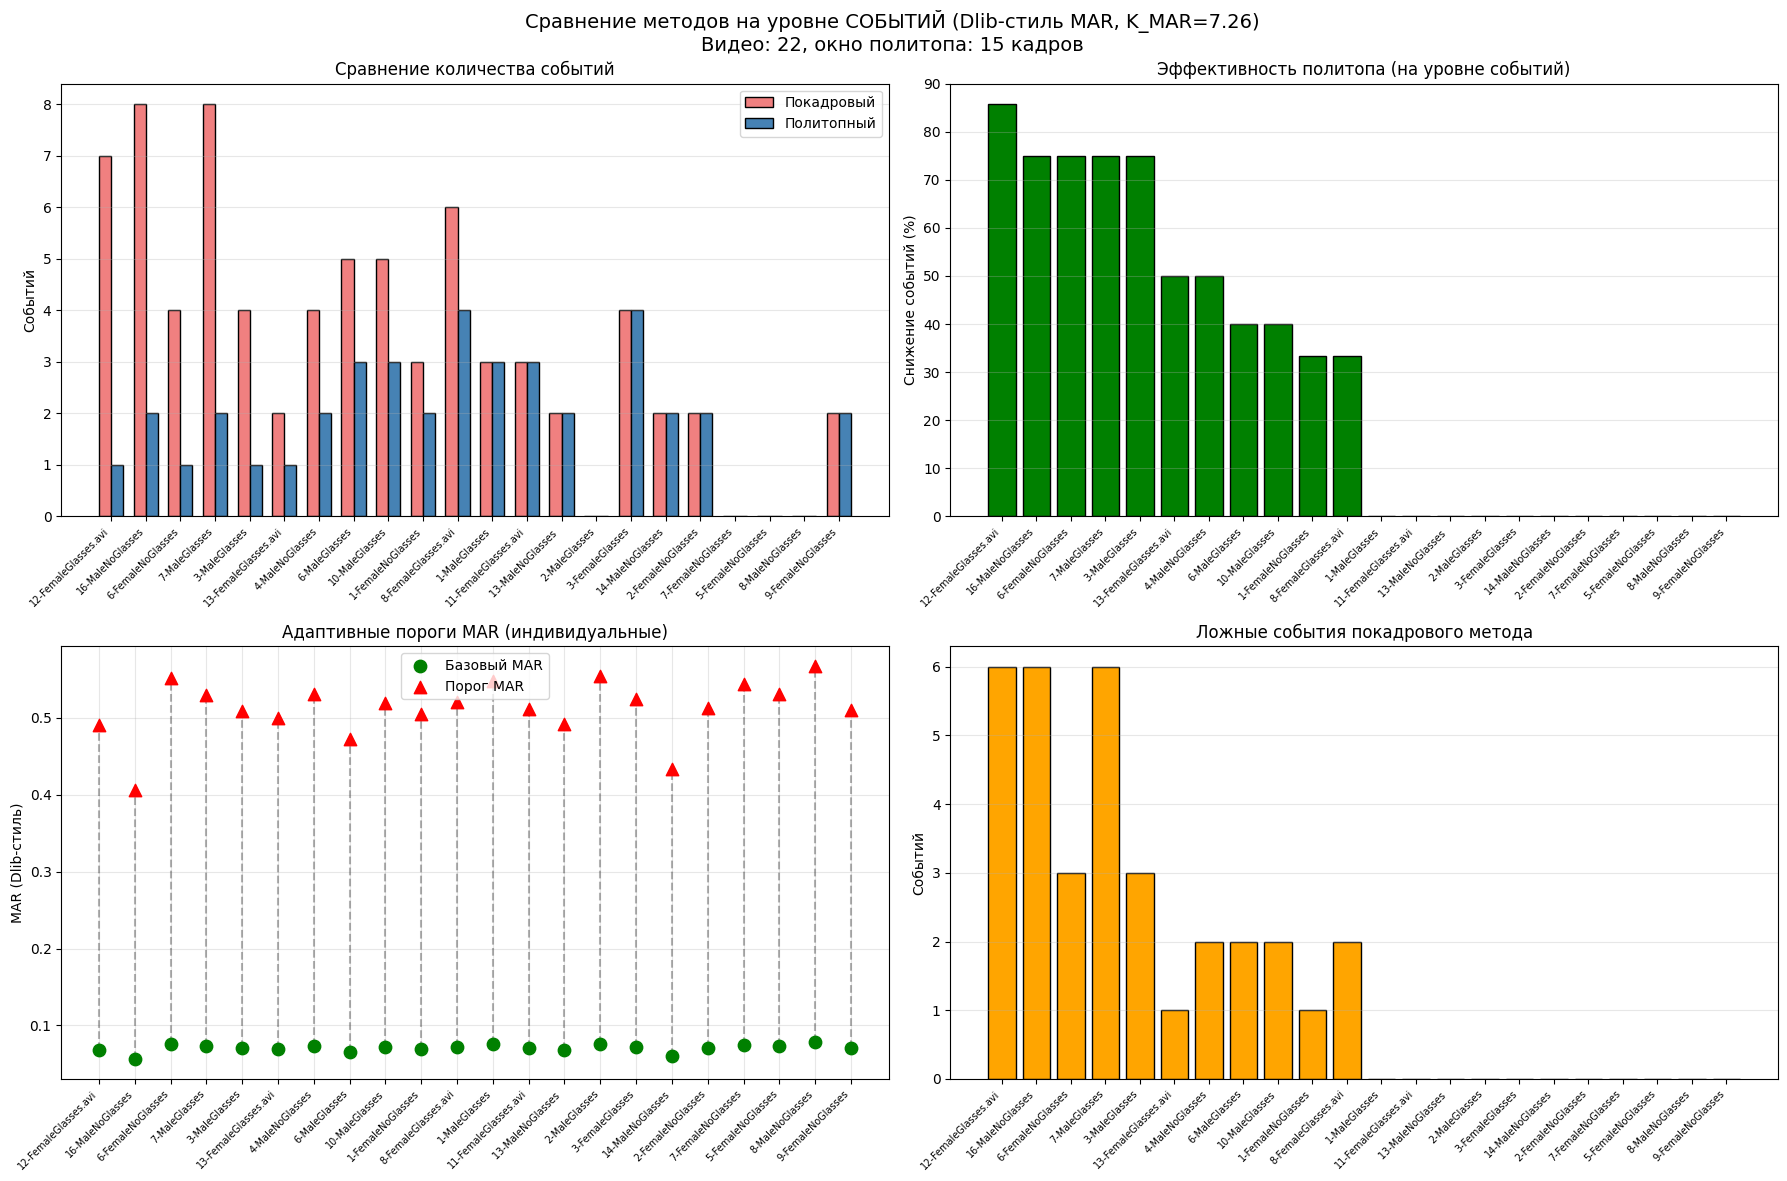

График сохранен: batch_results_dlib_mar\plots\batch_summary.png

ЭТАП 3: ОТЧЕТ
ОТЧЕТ: СРАВНЕНИЕ МЕТОДОВ ДЕТЕКЦИИ ЗЕВКА
Дата: 2026-05-04 22:47:25
Видео: 22
Формула MAR: Dlib-стиль (3 замера)
K_MAR: 7.26, K_NOSE_CHIN: 1.38
Окно политопа: 15 кадров

Метрика: СРАВНЕНИЕ НА УРОВНЕ СОБЫТИЙ
Событие = непрерывная последовательность кадров с зевком.

1. СВОДНАЯ СТАТИСТИКА:
----------------------------------------
  Покадровых кадров: 2499
  Политопных кадров: 1813
  Покадровых событий: 74
  Политопных событий: 40
  Ложных событий:     34
  Общее снижение: 45.9%
  Среднее снижение по видео: 28.7%
  Медианное снижение: 16.7%

2. АДАПТИВНЫЕ ПОРОГИ И СОБЫТИЯ ПО ВИДЕО:
----------------------------------------
  12-FemaleGlasses.avi:
    Базовый MAR: 0.0676, Порог: 0.4907
    Событий: покадровых 7, политопных 1, ложных 6, снижение 85.7%
  16-MaleNoGlasses:
    Базовый MAR: 0.0560, Порог: 0.4067
    Событий: покадровых 8, политопных 2, ложных 6, снижение 75.0%
  6-FemaleNoGlasses:
    Базовый MAR: 0.07

In [12]:
def main():
    """Главная функция."""
    print("=" * 70)
    print("ПАКЕТНЫЙ АНАЛИЗ: ПОЛИТОП vs ПОКАДРОВЫЙ (DLIB-СТИЛЬ MAR)")
    print("=" * 70)

    extractor = FaceMetricsExtractor()
    analyzer = SingleVideoAnalyzer(config, extractor)
    comparator = BatchComparator(config, analyzer)
    visualizer = BatchVisualizer(config)
    reporter = ReportGenerator(config)

    print("\nЭТАП 1: АНАЛИЗ ВИДЕО")
    df_results = comparator.run()

    if df_results is None:
        print("Нет результатов.")
        return None

    print("\nЭТАП 2: ВИЗУАЛИЗАЦИЯ")
    visualizer.plot_summary(df_results)

    print("\nЭТАП 3: ОТЧЕТ")
    reporter.generate(df_results)

    print("\nГОТОВО.")
    return df_results


if __name__ == "__main__":
    results = main()

# Сравнение методов детекции зевка: 1D-политоп (пакетная обработка)

## Методология

**Выборка:** 29 видео из датасета YawDD. После фильтрации по критерию достаточности нейтральных кадров (≥10% от длительности) оставлено 22 видео.

**Формула MAR:** Dlib-стиль с тремя вертикальными замерами.

**Адаптивная калибровка:** индивидуальная для каждого видео. Базовый MAR — медиана нейтральных кадров. Порог MAR = базовый × K_MAR.

**Параметры:**
- K_MAR = 7.26, K_NOSE_CHIN = 1.38, K_EAR = 0.6
- Окно политопа: 15 кадров
- Критерий исключения: нейтральных кадров < 10% от длительности видео

**Метрика:** сравнение на уровне событий.

## Результаты

### Сводная статистика

| Метрика | Значение |
|:---|:---|
| Видео обработано | 22 из 29 |
| Покадровых событий (всего) | 74 |
| Политопных событий (всего) | 40 |
| Ложных событий | 34 |
| Общее снижение | 45.9% |
| Среднее снижение по видео | 28.7% |
| Медианное снижение | 16.7% |

### Адаптивные пороги

Базовый MAR варьируется от **0.0560 до 0.0782** (разброс 1.4×), что подтверждает индивидуальные различия в анатомии губ. Пороги MAR варьируются от **0.4067 до 0.5677**.

### Интерпретация

Политопный подход на уровне событий продемонстрировал снижение ложных срабатываний на 45.9% (общее) и 28.7% (среднее по видео). На 12 видео снижение составило 0%, что подтверждает: политоп не пропускает длительные зевки, а фильтрует только кратковременные события.

Метрика на уровне событий исключает артефакты на границах зевка (начало и конец), где покадровый метод срабатывает раньше, чем заполняется окно политопа.